python distribution: /mnt/hdd1/sterbini/IPAC2026_NL_matching/miniconda/bin/python

Goal: express the Hénon map as a real lattice and verify their equivalence,
then use the RDT formalism to reconstruct invariant tori analytically.

Pipeline:
  1. Track particles in the Hénon map (reference)
  2. Build an xtrack line whose one-turn map equals the Hénon map
     (sextupole + linear rotation, with β=1 at the sext location)
  3. Match 12 quadrupoles to enforce the correct tune and β-function
  4. Track with xtrack and overlay on the Hénon phase portrait
  5. Compute Resonance Driving Terms (RDTs) at first order
  6. Reconstruct tori from the phasor expansion:
       X - i·Px = Σ_n  phasors[n] · exp(i·n·φ)
     and compare with tracking


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import xobjects as xo
import xtrack as xt
import nafflib
import pytori as pt

1. Hénon map — reference tracking and harmonic analysis
   The Hénon map is a 2D symplectic map that models a thin sextupole
   followed by a phase-space rotation by 2π·Q0.
   With β=1 and gemitt=1 at the sext, the kick strength is h1 = -i/4
   and the coordinate x plays the role of √(2·Ix)·cos(φ).


Text(0.5, 1.0, 'Hénon map phase portrait')

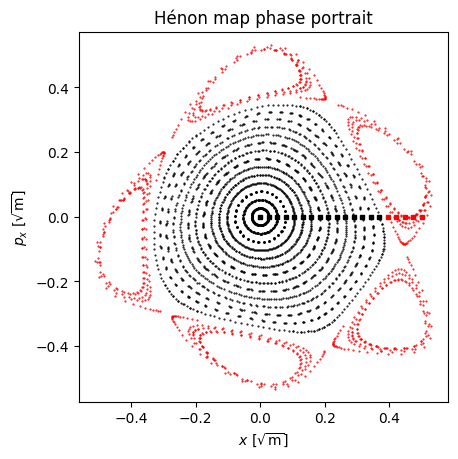

In [2]:
x_tori_number       = 20
x_start             = np.linspace(0.0001, 0.5, x_tori_number)
angular_points_number = 100

num_turns   = int(5e3)
Q0          = 0.2071   # bare tune (fractional part)

px_start = 0. * x_start

tori         = []
tracking_list = []
for x0, px0 in zip(x_start, px_start):
    x, px = nafflib.henon_map(x0, px0, Q0, num_turns)
    _tracking = {'x': x, 'px': px}

    # NAFF harmonic analysis: extract amplitudes Ax and frequencies Qx
    n_harm, w_order = 50, 4
    Ax, Qx = nafflib.harmonics(x, px, num_harmonics=n_harm, window_order=w_order)
    _tracking['Ax'] = Ax
    _tracking['Qx'] = Qx

    # Express each frequency as an integer linear combination of the tune Qx[0]
    nx = nafflib.linear_combinations(Qx, Qvec=[Qx[0]],
                                     max_n=90, max_alias=50,
                                     warning_tol=np.inf)
    _tracking['nx'] = nx

    tori.append(pt.Torus.from_naff(n=[nx], A=[Ax]))
    tracking_list.append(_tracking)

# Plot Hénon phase portrait (first 200 turns, black = stable, red = large amplitude)
n_plot = 200
for t in tracking_list[:15]:
    plt.plot(t['x'][:n_plot], t['px'][:n_plot], '.', color='k', markersize=1)
for t in tracking_list[15:]:
    plt.plot(t['x'][:n_plot], t['px'][:n_plot], '.', color='r', markersize=1)
for t in tracking_list[:15]:
    plt.plot(t['x'][0], t['px'][0], 's', color='k', markersize=3)
for t in tracking_list[15:]:
    plt.plot(t['x'][0], t['px'][0], 's', color='r', markersize=3)
plt.axis('equal')
plt.gca().set_box_aspect(1)
plt.xlabel(r'$x\ [\sqrt{\mathrm{m}}]$')
plt.ylabel(r'$p_x\ [\sqrt{\mathrm{m}}]$')
plt.title('Hénon map phase portrait')

2. Build the xtrack line — Hénon-equivalent lattice
   One cell = thin sextupole at the start (β=1, α=0) + linear segment.
   The sextupole strength k2l is derived from the Hénon h1 parameter via:
       h1 = -i/4  →  k2l = -i·8·h1 / β^(3/2) / √gemitt
   N quadrupoles are then used to realise the required phase advance.


In [3]:
N, Lq, Ld = 12, 0.2, 1.0   # number of quads, quad length [m], drift length [m]

twiss_init = {'betx': 1, 'alfx': 0}
gemitt_x   = 1
h1  = -1j / 4
k2l = -1j * 8 * h1 / twiss_init['betx']**(3/2) / gemitt_x**(1/2)
assert np.imag(k2l) == 0, "k2l must be real"
k2l = np.real(k2l)

line = xt.Line(elements={
    'tr.start'  : xt.Marker(),
    'sext'      : xt.Multipole(knl=[0, 0, k2l], ksl=[0, 0, 0], length=0),
    # ==========================
    'd0'        : xt.Drift(length=Ld),
    'q1'        : xt.Quadrupole(length=Lq, k1=0.0),
    # --------------------------
    'd1'        : xt.Drift(length=Ld),
    'q2'        : xt.Quadrupole(length=Lq, k1=0.0),
    # --------------------------
    'd2'        : xt.Drift(length=Ld),
    'q3'        : xt.Quadrupole(length=Lq, k1=0.0),
    # --------------------------
    'd3'        : xt.Drift(length=Ld),
    'q4'        : xt.Quadrupole(length=Lq, k1=0.0),
    # --------------------------
    'd4'        : xt.Drift(length=Ld),
    'q5'        : xt.Quadrupole(length=Lq, k1=0.0),
    # --------------------------
    'd5'        : xt.Drift(length=Ld),
    'q6'        : xt.Quadrupole(length=Lq, k1=0.0),
    # --------------------------
    'd6'        : xt.Drift(length=Ld),
    'q7'        : xt.Quadrupole(length=Lq, k1=0.0),
    # --------------------------
    'd7'        : xt.Drift(length=Ld),
    'q8'        : xt.Quadrupole(length=Lq, k1=0.0),
    # --------------------------
    'd8'        : xt.Drift(length=Ld),
    'q9'        : xt.Quadrupole(length=Lq, k1=0.0),
    # --------------------------
    'd9'        : xt.Drift(length=Ld),
    'q10'       : xt.Quadrupole(length=Lq, k1=0.0),
    # --------------------------
    'd10'       : xt.Drift(length=Ld),
    'q11'       : xt.Quadrupole(length=Lq, k1=0.0),
    # --------------------------
    'd11'       : xt.Drift(length=Ld),
    'q12'       : xt.Quadrupole(length=Lq, k1=0.0),
    # ==========================
    'd_end'     : xt.Drift(length=Ld),
    'tr.end'    : xt.Marker(),
})
line.particle_ref = xt.Particles(p0c=7e12, mass0=xt.PROTON_MASS_EV, q0=1)

# Expose quad strengths as independent knobs
for i in range(N):
    line.vars[f'k{i+1}'] = 0.0
    line.element_refs[f'q{i+1}'].k1 = line.vars[f'k{i+1}']

3. Match the lattice
   Constraints: βx=βy=1, αx=αy=0 at both ends (periodic-cell-like),
   total phase advance μx = 1 + Q0 (integer + fractional tune).
   The y plane is left free (only one tune target here).


Compiling ContextCpu kernels...


Done compiling ContextCpu kernels.
                                             


Optimize - start penalty: 4.255e-11                         



Optimize - end penalty:  4.25529e-11                            
μx = 1.207100,  μy = 0.820482


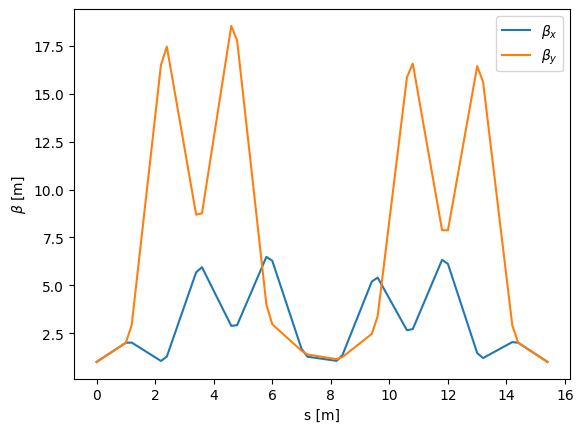

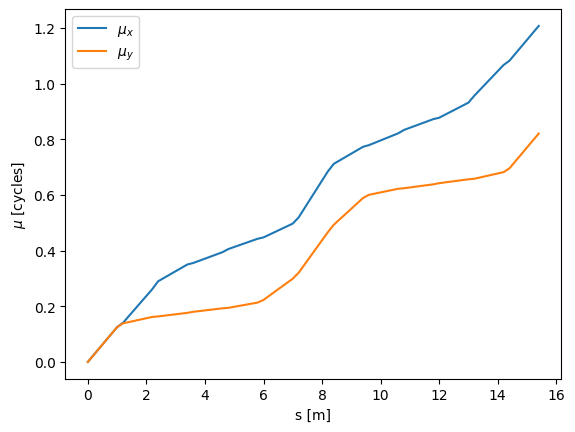

In [4]:
seed = [5.033571436491605,
        -4.320388955493479,
        4.3661443771168695,
        -4.155299019583114,
        4.229837411481433,
        -1.510083731703031,
        -1.520774771579453,
        4.209451369946942,
        -4.207158224932284,
        4.471753297307329,
        -4.3479587631873855,
        4.70666622112177,
        ]
for i, k in enumerate(seed):
    line.vars[f'k{i+1}'] = k

mux0 = 1 + Q0   # total phase advance in cycles (integer + fractional)
line.match(
    betx=1, bety=1, alfx=0, alfy=0,
    vary=[xt.VaryList([f'k{i+1}' for i in range(N)], step=1e-5)],
    targets=[
        xt.Target('betx', 1.0, at='tr.end'),
        xt.Target('alfx', 0.0, at='tr.end'),
        xt.Target('bety', 1.0, at='tr.end'),
        xt.Target('alfy', 0.0, at='tr.end'),
        xt.Target('mux',  mux0, at='tr.end'),
    ],
)

# Plot matched Twiss functions along the cell
init = xt.TwissInit(betx=1.0, alfx=0.0, bety=1.0, alfy=0.0,
                    element_name='tr.start', line=line)
tw = line.twiss(method='4d', init=init, start='tr.start', end='tr.end')

plt.figure()
plt.plot(tw['s'], tw['betx'], label=r'$\beta_x$')
plt.plot(tw['s'], tw['bety'], label=r'$\beta_y$')
plt.xlabel('s [m]')
plt.ylabel(r'$\beta$ [m]')
plt.legend()

plt.figure()
plt.plot(tw['s'], tw['mux'], label=r'$\mu_x$')
plt.plot(tw['s'], tw['muy'], label=r'$\mu_y$')
plt.xlabel('s [m]')
plt.ylabel(r'$\mu$ [cycles]')
plt.legend()
print(f"μx = {tw.mux[-1]:.6f},  μy = {tw.muy[-1]:.6f}")

4. xtrack tracking — verify Hénon ↔ lattice equivalence
   We freeze the longitudinal plane.
   Particles are initialised in Courant–Snyder normalised coordinates
   at the sextupole location (βx=1, αx=0) using the matched W matrix.


Compiling ContextCpu kernels...


Done compiling ContextCpu kernels.



Tracking:   0%|          | 0/5000 [00:00<?, ?it/s]

Compiling ContextCpu kernels...



Tracking:   2%|▏         | 100/5000 [00:22<18:28,  4.42it/s]


Tracking:  50%|█████     | 2500/5000 [00:22<00:16, 155.00it/s]

Done compiling ContextCpu kernels.



Tracking:  98%|█████████▊| 4900/5000 [00:22<00:00, 366.77it/s]


Tracking: 100%|██████████| 5000/5000 [00:22<00:00, 219.02it/s]

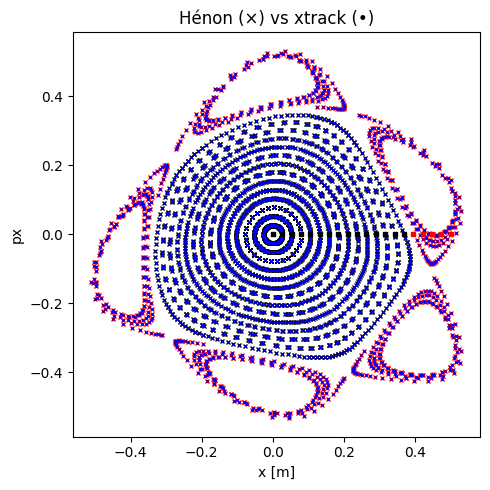

In [5]:
context      = xo.ContextCpu(omp_num_threads='auto')
particle_ref = xt.Particles(p0c=7e12, q0=1, mass0=xt.PROTON_MASS_EV)
line.particle_ref = particle_ref
line.freeze_longitudinal(True)
twiss = line.twiss4d()

num_turns = int(5e3)
particles = line.build_particles(
    x_norm              = x_start,
    method              = '4d',
    nemitt_x            = None,
    nemitt_y            = None,
    nemitt_zeta         = None,
    W_matrix            = twiss.W_matrix[0],
    particle_on_co      = twiss.particle_on_co.copy(),
    _context            = context,
)
line.config.XTRACK_GLOBAL_XY_LIMIT = 3
line.track(particles, num_turns=num_turns, turn_by_turn_monitor=True, with_progress=True)

mon    = line.record_last_track
n_plot = 200

# Overlay Hénon (crosses) and xtrack (dots) — they should coincide
plt.figure(figsize=(5, 5))
for t in tracking_list[:15]:
    plt.plot(t['x'][:n_plot], t['px'][:n_plot], 'x', color='k', markersize=3)
for t in tracking_list[15:]:
    plt.plot(t['x'][:n_plot], t['px'][:n_plot], 'x', color='r', markersize=3)
for ii in range(x_tori_number):
    plt.plot(mon.x[ii, :n_plot], mon.px[ii, :n_plot], '.b', markersize=2)
for t in tracking_list[:15]:
    plt.plot(t['x'][0], t['px'][0], 's', color='k', markersize=3)
for t in tracking_list[15:]:
    plt.plot(t['x'][0], t['px'][0], 's', color='r', markersize=3)
plt.xlabel('x [m]')
plt.ylabel('px')
plt.title('Hénon (×) vs xtrack (•)')
plt.tight_layout()

5. Resonance Driving Terms (RDTs) — first-order perturbation theory
   Reference: xtrack physics manual, chapter "Resonant Driving Terms".

   An RDT labelled f_{pqrt} drives a spectral line of X-i·Px at harmonic
     n = q - p + 1
   i.e. the harmonic index n of the spectral decomposition:
     X - i·Px = Σ_n  A_n(Ix) · exp(i·n·φ)

   The dictionary my_dict[n] lists all f_{pq00} contributing to harmonic n.
   Active harmonics (uncomment to include):
     n = -2 : f3000  (3rd-order resonance sideband)
     n =  0 : f2100  (amplitude-dependent tune shift)
     n =  2 : f0100, f1200, f2300  (detuned fundamental and sidebands)
   Higher harmonics (n = 3,4,5) can be enabled by uncommenting below.


In [6]:
strengths = line.get_strengths()
from xtrack import rdt_first_order_perturbation

my_dict = {}

# At first order in sextupole strength, only RDTs with p+q = 3 (r=t=0) are non-zero.
# The four f_{pq00} with p+q=3 cover harmonics n = q-p+1 ∈ {-2, 0, +2, +4}.
my_dict[-2] = ['f3000']   # p=3, q=0  →  n = 0-3+1 = -2
my_dict[ 0] = ['f2100']   # p=2, q=1  →  n = 1-2+1 =  0
my_dict[ 2] = ['f1200']   # p=1, q=2  →  n = 2-1+1 = +2
my_dict[ 4] = ['f0300']   # p=0, q=3  →  n = 3-0+1 = +4  (amplitude = 0: p=0 kills the -2j·p² prefactor)

# Evaluate RDTs at the sextupole location — independent of the action Ix
rdt_results = {}
for nn in my_dict:
    rdt_results[nn] = rdt_first_order_perturbation(
        rdt      = my_dict[nn],
        twiss    = twiss,
        strengths = strengths,
        feed_down = True,
    )

Compiling ContextCpu kernels...


Done compiling ContextCpu kernels.


6. Reconstruct tori from the phasor expansion
   At first order in the sextupole strength, the complex coordinate
   Z = X - i·Px can be written as:

     Z(φ, Ix) = Σ_n  phasors[n](Ix) · exp(i·n·φ)

   where the fundamental phasor (n=1) is just √(2·Ix) and the
   perturbed phasors at harmonic n are:
     phasors[n] = Σ_{f_{pq}∈my_dict[n]}  -2i·p² · (2·Ix)^{(p+q-1)/2} · f_{pq}

   Tori are parametric curves (X(φ), Px(φ)) = (Re Z, -Im Z).
   Spacing: √Ix linearly spaced → equally spaced rings in amplitude.


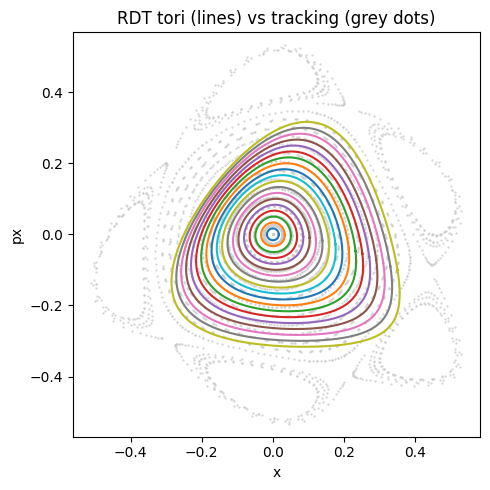

In [7]:
phi = np.linspace(0, 2 * np.pi, 1000)

plt.figure(figsize=(5, 5))

# Overlay tracking for comparison
for ii in range(x_tori_number):
    plt.plot(mon.x[ii, :n_plot], mon.px[ii, :n_plot], '.', color='0.8', markersize=1)

for Ix in np.linspace(0, np.sqrt(0.05), 20)[1:]**2:  # Ix values are arbitrary — chosen to show topology, not to match tracking amplitudes
    phasors = {1: np.sqrt(2 * Ix)}   # unperturbed fundamental
    for nn in my_dict:
        c = 0
        for rdt in my_dict[nn]:
            p, q = int(rdt[1]), int(rdt[2])
            # first-order contribution: -2i·p² · (2Ix)^{(p+q-1)/2} · f_{pq}
            c += -2j * p**2 * (2 * Ix)**((p + q - 1) / 2) * rdt_results[nn][rdt][0]
        phasors[nn] = c

    z = sum(phasors[nn] * np.exp(1j * nn * phi) for nn in phasors)
    plt.plot(np.real(z), -np.imag(z))

plt.xlabel('x')
plt.ylabel('px')
plt.title('RDT tori (lines) vs tracking (grey dots)')
plt.axis('equal')
plt.tight_layout()
# %%